## Qwen2.5-VL로 최신 Vision-Language Model 사용
- 이미지와 텍스트를 함 입력 받아 대화형으로 응답을 생성할 수 있는 모델

In [1]:
!pip install transformers accelerate qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 64.0 MB/s eta 0:00:00


## Model / Processor 로드

https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct

In [2]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

model_id = 'Qwen/Qwen2.5-VL-3B-Instruct'

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map='auto'
)
model.eval()

min_pixels = 256 * 28 * 28
max_pixels = 512 * 28 * 28

processor = AutoProcessor.from_pretrained(
    model_id,
    min_pixels=min_pixels,
    max_pixels=max_pixels
)

print('모델 로드 완료 :', model_id)


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

모델 로드 완료 : Qwen/Qwen2.5-VL-3B-Instruct


## 예제 이미지 준비

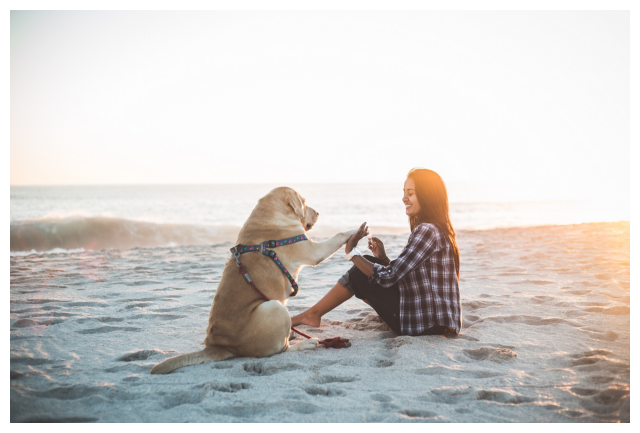

In [3]:
import requests
import matplotlib.pyplot as plt
from PIL import Image

image_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'

image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## Qwen2.5-VL 입력 형식

In [9]:
messages = [
    {
        'role' : 'user',
        'content' : [
            {'type' : 'image', 'image' : image_url},
            {'type' : 'text', 'text' : '이 이미지를 한국어로 설명해줘.'},
        ],
    }
]

# 대화 메세지를 모델 입력용 텍스트 프롬프트로 변환
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    # add_generate_prompt=True,
    add_generation_prompt=True,
)

# 메세지 안의 이미지 정보를 모델 입력으로 변환하기 위해 분리한다.
image_inputs, video_inputs = process_vision_info(messages)

print(text[:500])
print('이미지 입력 개수 : ', len(image_inputs))
print('비디오 입력 : ', video_inputs)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>이 이미지를 한국어로 설명해줘.<|im_end|>
<|im_start|>assistant

이미지 입력 개수 :  1
비디오 입력 :  None


## 이미지 설명 생성

In [10]:
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors='pt'
)

inputs = inputs.to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=128
    )

# generated 결과에는 입력 프롬프트 값도 포함 된다.
# 새로 생성 된 토큰만 보기 위해 잘라낸다.
generated_ids_trimmed = [
    output_ids[len(input_ids):]
    for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
]
answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

print(answer)

이 사진은 해변에서 한 여성이 강아지와 함께 시간을 보내고 있는 모습을 담고 있습니다. 여성은 체크무늬 셔츠를 입고 있으며, 강아지는 흰색의 라ブラ도르 리트리버입니다. 두 사람은 바다를 바라보며 서로를 바라보고 있는 듯한 포즈를 취하고 있습니다. 해가 지는 시간에 맞춰 조명이 아름답게 비추고 있어, 평화롭고 따뜻한 분위기를 연출하고 있습니다.


## 반복 사용을 위한 함수 선언

In [11]:
def ask_image(image_source, question, max_new_tokens=128):
  messages = [
    {
        'role' : 'user',
        'content' : [
            {'type' : 'image', 'image' : image_source},
            {'type' : 'text', 'text' : question},
        ],
    }
  ]

  text = processor.apply_chat_template(
      messages,
      tokenize=False,
      add_generation_prompt=True,
  )

  image_inputs, video_inputs = process_vision_info(messages)

  inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors='pt'
  )

  inputs = inputs.to(model.device)

  with torch.no_grad():
      generated_ids = model.generate(
          **inputs,
          max_new_tokens=128
      )

  generated_ids_trimmed = [
      output_ids[len(input_ids):]
      for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
  ]

  answer = processor.batch_decode(
      generated_ids_trimmed,
      skip_special_tokens=True,
      clean_up_tokenization_spaces=False
  )[0]

  return answer

## 이미지 기반의 질문 답변

In [13]:
questions = [
    '이 이미지에 무엇이 보이는지 한 문단으로 설명해줘.',
    '이미지 속 주요 객체를 목록으로 정리해줘.',
    '강아지는 무엇을 하고 있는 것처럼 보이나?',
    '이 이미지를 검색 시스템에 저장한다면 어떤 키워드를 메타데이터로 넣으면 좋을까?'
]

for question in questions:
  answer = ask_image(image_url, question, max_new_tokens=128)
  print('Q:', question)
  print('A:', answer)
  print('-' * 100)

Q: 이 이미지에 무엇이 보이는지 한 문단으로 설명해줘.
A: 이 이미지는 해변에서 여성이 강아지를 둘러싸고 있는 모습을 보여줍니다. 여성은 체크무늬 셔츠를 입고 있으며, 강아지는 흰색의 라ブラ도르 러브리입니다. 두 사람은 서로를 바라보며, 여성은 강아지의 손가락을 향해 손을 내밀고 있습니다. 해변의 모래 위에는 여러 개의 발자국이 남아 있으며, 배경에는 바다와 하늘을 볼 수 있습니다.
----------------------------------------------------------------------------------------------------
Q: 이미지 속 주요 객체를 목록으로 정리해줘.
A: 1. 여자
2. 강아지
3. 해변
4. 바다
5. 태양
6. 해질녘
7. 햇빛
8. 해변의 모래
9. 강아지의 목줄
10. 여자의 옷

이 목록은 이미지에서 가장 주요하게 보이는 객체들을 포함하고 있습니다.
----------------------------------------------------------------------------------------------------
Q: 강아지는 무엇을 하고 있는 것처럼 보이나?
A: 그림에서 강아지는 사람에게 손가락을 향하고 있는 것처럼 보입니다. 이는 강아지가 사람에게 무언가를 요청하거나, 사람들과의 상호작용을 나타내는 행동일 수 있습니다.
----------------------------------------------------------------------------------------------------
Q: 이 이미지를 검색 시스템에 저장한다면 어떤 키워드를 메타데이터로 넣으면 좋을까?
A: 이 이미지의 메타데이터를 저장할 때는 다음과 같은 키워드를 사용하는 것이 좋습니다:

1. 해변 (beach)
2. 강아지 (dog)
3. 여자 (woman)
4. 야외 (outdoor)
5. 일몰 (sunset)
6. 행복 (happy)
7. 친구 (friendship)
8. 자연 (n

## 구조화 된 출력 요청

In [14]:
structured_prompt = """
이 이미지를 검색 시스템에 저장하기 위한 메타데이터를 만들어줘.
아래 형식을 최대한 지켜서 한국어로 답해줘.

{
  "summary" : "이미지 한 줄 요약",
  "objects" : ["주요 객체1", "주요 객체2"],
  "scene" : "장소나 배경 설명",
  "keywords" : ["검색 키워드1", "검색 키워드2", "검색 키워드3"]
}
"""

answer = ask_image(image_url, structured_prompt, max_new_tokens=256)
print(answer)

```json
{
  "summary": "사람과 강아지가 해변에서 즐기는 순간",
  "objects": ["사람", "강아지"],
  "scene": "해변, 해안가, 해질녘의 조명",
  "keywords": ["사랑", "동물", "해변", "일몰", "사랑하는 사람", "강아지", "행복한 시간"]
}
```


## 다른 이미지로 테스트

In [15]:
new_image_url = 'http://images.cocodataset.org/val2017/000000039769.jpg'

new_questions = [
    '이 이미지에는 무엇이 보이나?',
    '이미지 안의 글자나 라벨에서 읽을 수 있는 정보가 있으면 말해줘',
    '이미지안에 생명체가 있나?',
    '이미지 안의 객체의 숫자는 몇개인가?'
]


for question in new_questions:
  answer = ask_image(new_image_url, question, max_new_tokens=128)
  print('Q:', question)
  print('A:', answer)
  print('-' * 100)

Q: 이 이미지에는 무엇이 보이나?
A: 이 이미지는 두 마리의 고양이가 분홍색 소파 위에 누워 있는 모습을 보여줍니다. 고양이들은 각각 다른 방향을 바라보고 있으며, 한 마리는 손가락을 펴고 있습니다. 고양이들은 주변에 두 개의 컨트롤러가 놓여 있습니다.
----------------------------------------------------------------------------------------------------
Q: 이미지 안의 글자나 라벨에서 읽을 수 있는 정보가 있으면 말해줘
A: No, there is no text or label visible in the image that can be read.
----------------------------------------------------------------------------------------------------
Q: 이미지안에 생명체가 있나?
A: 네, 이미지에는 두 마리의 고양이가 있습니다.
----------------------------------------------------------------------------------------------------
Q: 이미지 안의 객체의 숫자는 몇개인가?
A: 이 이미지에는 두 마리의 고양이가 있습니다.
----------------------------------------------------------------------------------------------------
